# Data Cleaning

## 1. Imputing Missing Values

 Missing values, occur when no data value is stored for the variable in an observation. 
 
 The problem of missing data is relatively common in almost all research and can have a significant effect on the conclusions that can be drawn from the data, the lost data can cause bias in the estimation of parameters or it can also reduce the representativeness of the samples.

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Load the dataset with error handling
try:
    data3 = pd.read_csv("fifa.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: fifa.csv not found. Ensure it's in the current directory.")
# Display first few rows and info
print(data3.head())
print(data3.info())  # Shows data types and non-null counts

Dataset loaded successfully.
   Unnamed: 0      ID               Name  Age  \
0           0  158023           L. Messi   31   
1           1   20801  Cristiano Ronaldo   33   
2           2  190871          Neymar Jr   26   
3           3  193080             De Gea   27   
4           4  192985       K. De Bruyne   27   

                                            Photo Nationality  \
0  https://cdn.sofifa.org/players/4/19/158023.png   Argentina   
1   https://cdn.sofifa.org/players/4/19/20801.png    Portugal   
2  https://cdn.sofifa.org/players/4/19/190871.png      Brazil   
3  https://cdn.sofifa.org/players/4/19/193080.png       Spain   
4  https://cdn.sofifa.org/players/4/19/192985.png     Belgium   

                                  Flag  Overall  Potential  \
0  https://cdn.sofifa.org/flags/52.png       94         94   
1  https://cdn.sofifa.org/flags/38.png       94         94   
2  https://cdn.sofifa.org/flags/54.png       92         93   
3  https://cdn.sofifa.org/flags/45.pn

In [8]:
data3.dtypes

Unnamed: 0          int64
ID                  int64
Name                  str
Age                 int64
Photo                 str
                   ...   
GKHandling        float64
GKKicking         float64
GKPositioning     float64
GKReflexes        float64
Release Clause        str
Length: 89, dtype: object

In [9]:
data3.describe()

,Unnamed: 0,ID,Age,Overall,Potential,Special,International Reputation,Weak Foot,Skill Moves,Jersey Number,...,Penalties,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
count,18207.000000,18207.000000,18207.000000,18207.000000,18207.000000,18207.000000,18159.000000,18159.000000,18159.000000,18147.000000,...,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000,18159.000000
mean,9103.000000,214298.338606,25.122206,66.238699,71.307299,1597.809908,1.113222,2.947299,2.361308,19.546096,...,48.548598,58.648274,47.281623,47.697836,45.661435,16.616223,16.391596,16.232061,16.388898,16.710887
std,5256.052511,29965.244204,4.669943,6.908930,6.136496,272.586016,0.394031,0.660456,0.756164,15.947765,...,15.704053,11.436133,19.904397,21.664004,21.289135,17.695349,16.906900,16.502864,17.034669,17.955119
min,0.000000,16.000000,16.000000,46.000000,48.000000,731.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,3.000000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4551.500000,200315.500000,21.000000,62.000000,67.000000,1457.000000,1.000000,3.000000,2.000000,8.000000,...,39.000000,51.000000,30.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,9103.000000,221759.000000,25.000000,66.000000,71.000000,1635.000000,1.000000,3.000000,2.000000,17.000000,...,49.000000,60.000000,53.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,13654.500000,236529.500000,28.000000,71.000000,75.000000,1787.000000,1.000000,3.000000,3.000000,26.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,18206.000000,246620.000000,45.000000,94.000000,95.000000,2346.000000,5.000000,5.000000,5.000000,99.000000,...,92.000000,96.000000,94.000000,93.000000,91.000000,90.000000,92.000000,91.000000,90.000000,94.000000


In [10]:
data3.isnull().sum()

Unnamed: 0           0
ID                   0
Name                 0
Age                  0
Photo                0
                  ... 
GKHandling          48
GKKicking           48
GKPositioning       48
GKReflexes          48
Release Clause    1564
Length: 89, dtype: int64

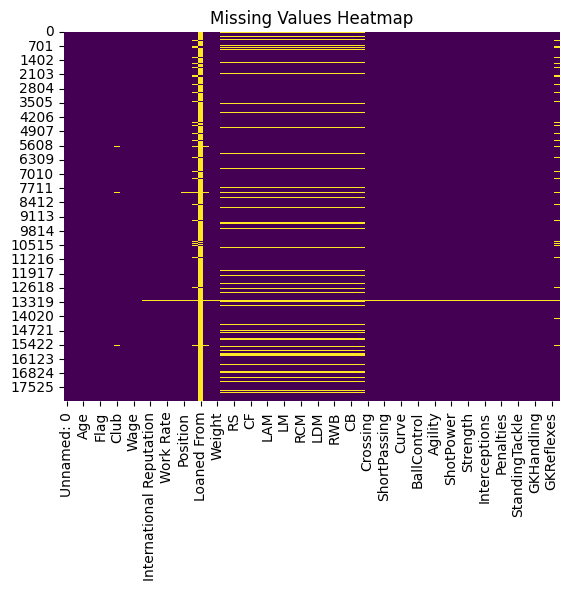

In [11]:
# Heatmap of missing values
sns.heatmap(data3.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [12]:
x=data3.isnull().sum()
y=(data3.isnull().sum()/data3.shape[0])*100
z={'Number of missing values':x,'Percentage of missing values':y}
df=pd.DataFrame(z,columns=['Number of missing values','Percentage of missing values'])
df.sort_values(by='Percentage of missing values',ascending=False)

,Number of missing values,Percentage of missing values
Loaned From,16943,93.057615
RWB,2085,11.451639
RDM,2085,11.451639
CDM,2085,11.451639
LDM,2085,11.451639
...,...,...
Photo,0,0.000000
Potential,0,0.000000
Flag,0,0.000000
Overall,0,0.000000


In [13]:
# Drop columns with very high missing (>90%)
data = data3.drop(['Loaned From'], axis=1)  
data.columns

Index(['Unnamed: 0', 'ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag',
       'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special',
       'Preferred Foot', 'International Reputation', 'Weak Foot',
       'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position',
       'Jersey Number', 'Joined', 'Contract Valid Until', 'Height', 'Weight',
       'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM',
       'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB',
       'LCB', 'CB', 'RCB', 'RB', 'Crossing', 'Finishing', 'HeadingAccuracy',
       'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy',
       'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility',
       'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength',
       'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle',
       'GKDivi

In [14]:
# Drop rows with >50 missing values (
print("Before dropping rows with >50 NaNs:", data.shape[0])
data = data[data.isnull().sum(axis=1) <= 50]
print("After dropping:", data.shape[0])

Before dropping rows with >50 NaNs: 18207
After dropping: 18159


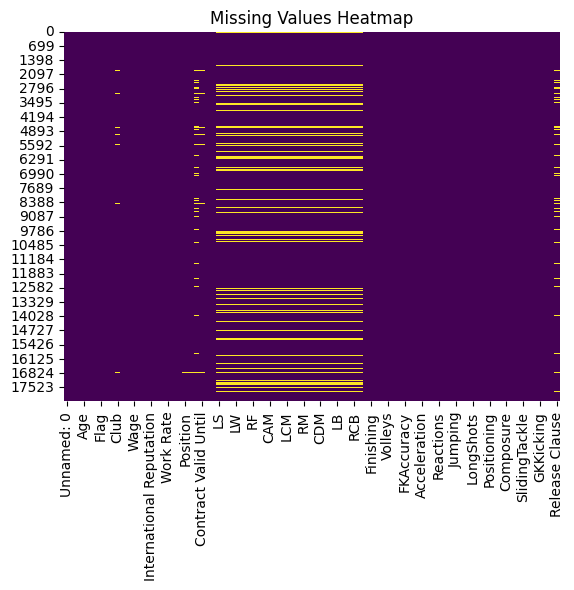

In [15]:
# Heatmap of missing values again
# Heatmap of missing values
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [16]:
# Identify columns with missing values
missing_cols = data.columns[data.isnull().any()]
missing_cols

Index(['Club', 'Position', 'Jersey Number', 'Joined', 'Contract Valid Until',
       'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM',
       'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB',
       'LCB', 'CB', 'RCB', 'RB', 'Release Clause'],
      dtype='str')

In [17]:
data.dtypes[data.isnull().any()]

Club                        str
Position                    str
Jersey Number           float64
Joined                      str
Contract Valid Until        str
LS                          str
ST                          str
RS                          str
LW                          str
LF                          str
CF                          str
RF                          str
RW                          str
LAM                         str
CAM                         str
RAM                         str
LM                          str
LCM                         str
CM                          str
RCM                         str
RM                          str
LWB                         str
LDM                         str
CDM                         str
RDM                         str
RWB                         str
LB                          str
LCB                         str
CB                          str
RCB                         str
RB                          str
Release 

In [18]:
# Technique 1: Mode for categorical/object columns
categorical_cols = ['Club', 'Position', 'Joined', 'Contract Valid Until']
for col in categorical_cols:
    if col in missing_cols:
        data[col] = data[col].fillna(data[col].mode()[0])
        print(f"Filled {col} with mode: {data[col].mode()[0]}")

Filled Club with mode: AS Monaco
Filled Position with mode: ST
Filled Joined with mode: Jul 1, 2018
Filled Contract Valid Until with mode: 2019


In [19]:
# Special handling for 'Jersey Number' (keep as float, fill with -1 )
if 'Jersey Number' in missing_cols:
    data['Jersey Number'] = data['Jersey Number'].fillna(-1)  # Sentinel value

In [20]:
data['Jersey Number']

0        10.0
1         7.0
2        10.0
3         1.0
4         7.0
         ... 
18202    22.0
18203    21.0
18204    33.0
18205    34.0
18206    33.0
Name: Jersey Number, Length: 18159, dtype: float64

In [21]:
data[['LS', 'ST', 'RS', 'LW']]

,LS,ST,RS,LW
0,88+2,88+2,88+2,92+2
1,91+3,91+3,91+3,89+3
2,84+3,84+3,84+3,89+3
3,NaN,NaN,NaN,NaN
4,82+3,82+3,82+3,87+3
...,...,...,...,...
18202,42+2,42+2,42+2,44+2
18203,45+2,45+2,45+2,39+2
18204,45+2,45+2,45+2,45+2
18205,47+2,47+2,47+2,47+2


In [22]:
# Technique 2: Fill with 0 for position ratings
position_ratings = ['LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM',
                    'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB']
for col in position_ratings:
    if col in missing_cols:
        data[col] = data[col].fillna('0+0')  # Improved: Keep as string format for consistency

In [23]:
data[col]

0        59+2
1        61+3
2        60+3
3         0+0
4        73+3
         ... 
18202    45+2
18203    29+2
18204    33+2
18205    35+2
18206    46+2
Name: RB, Length: 18159, dtype: str

In [24]:
# Technique 3: Convert currency columns to numeric and impute with median (better than mode)
data['Release Clause']

0        €226.5M
1        €127.1M
2        €228.1M
3        €138.6M
4        €196.4M
          ...   
18202      €143K
18203      €113K
18204      €165K
18205      €143K
18206      €165K
Name: Release Clause, Length: 18159, dtype: str

In [25]:
def currency_to_num(value):
    if isinstance(value, str):
        value = value.replace('€', '').replace('K', 'e3').replace('M', 'e6')
        return float(value)
    return value

if 'Release Clause' in missing_cols:
    data['Release Clause'] = data['Release Clause'].apply(currency_to_num)  # Convert to numeric
    data['Release Clause'] = data['Release Clause'].fillna(data['Release Clause'].median())  # Median is robust to outliers
    print("Filled 'Release Clause' with median after conversion.")

Filled 'Release Clause' with median after conversion.


In [26]:
data['Release Clause']

0        226500000.0
1        127100000.0
2        228100000.0
3        138600000.0
4        196400000.0
            ...     
18202       143000.0
18203       113000.0
18204       165000.0
18205       143000.0
18206       165000.0
Name: Release Clause, Length: 18159, dtype: float64

In [27]:
#Technique 4: Mean/Median for numerical columns 
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns
print(numerical_cols)
for col in numerical_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())  # Median for skewed data; use mean() for normal dist

Index(['Unnamed: 0', 'ID', 'Age', 'Overall', 'Potential', 'Special',
       'International Reputation', 'Weak Foot', 'Skill Moves', 'Jersey Number',
       'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys',
       'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl',
       'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance',
       'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots',
       'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties',
       'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving',
       'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes',
       'Release Clause'],
      dtype='str')


In [28]:
data[col].isnull().sum()

np.int64(0)

In [29]:
# Technique 5: Forward/Backward Fill (useful if data is sorted, e.g., by 'Age' or date)
data['Joined']

0         Jul 1, 2004
1        Jul 10, 2018
2         Aug 3, 2017
3         Jul 1, 2011
4        Aug 30, 2015
             ...     
18202     May 3, 2017
18203    Mar 19, 2018
18204     Jul 1, 2017
18205    Apr 24, 2018
18206    Oct 30, 2018
Name: Joined, Length: 18159, dtype: str

In [30]:
data['Joined'].isnull().sum()

np.int64(0)

In [31]:
data = data.sort_values('Joined')  # Assume 'Joined' is date-ordered
  # Forward then backward fill

In [34]:
data = data.fillna(value="ffill")

In [35]:
data = data.fillna('bfill')

In [36]:
# Technique 7: KNN Imputer (Learning-based or ml based, for numerical data)

In [37]:
# Final check
print("Total remaining NaNs:", data.isnull().sum().sum())

Total remaining NaNs: 0
